In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the test dataset and set the 'id' column as the index

df_train = pd.read_csv('../data/raw/train.csv', index_col='id')

df_train.head()

,date,store_nbr,family,sales,onpromotion
id,,,,,
0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,2013-01-01,1,BABY CARE,0.0,0
2,2013-01-01,1,BEAUTY,0.0,0
3,2013-01-01,1,BEVERAGES,0.0,0
4,2013-01-01,1,BOOKS,0.0,0


In [4]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 5 columns):
 #   Column       Dtype  
---  ------       -----  
 0   date         str    
 1   store_nbr    int64  
 2   family       str    
 3   sales        float64
 4   onpromotion  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 114.5 MB


In [6]:
df_train['date'] = pd.to_datetime(df_train['date'])

Vamos a estudiar el dataset, evaluando las características de cada campo

<font color='red' size=6>
    DATE
</font>

Este campo delimita la fecha de cada uno de los movimientos de las tiendas, con el vamos a obtener estadísticas estacionales

In [7]:
# Check the range of dates in the dataset
df_train['date'].describe()

count                       3000888
mean     2015-04-24 08:27:04.703088
min             2013-01-01 00:00:00
25%             2014-02-26 18:00:00
50%             2015-04-24 12:00:00
75%             2016-06-19 06:00:00
max             2017-08-15 00:00:00
Name: date, dtype: object

C:\Users\Facundo\AppData\Local\Temp\ipykernel_15716\2225175679.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_frecuency.index, y=month_frecuency.values, palette='viridis')


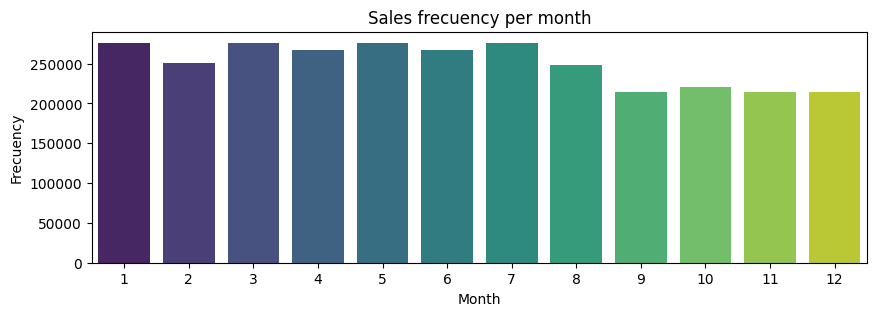

In [8]:
# sales frecuency per month

month_frecuency = df_train['date'].dt.month.value_counts().sort_index()

plt.figure(figsize=(10, 3))
sns.barplot(x=month_frecuency.index, y=month_frecuency.values, palette='viridis')
plt.title('Sales frecuency per month')
plt.xlabel('Month')
plt.ylabel('Frecuency')
plt.show()

C:\Users\Facundo\AppData\Local\Temp\ipykernel_15716\2665692880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_frecuency.index, y=day_frecuency.values, palette='viridis')


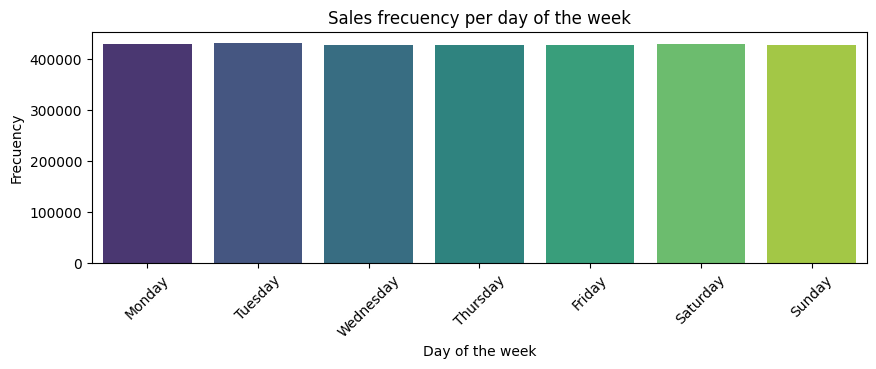

In [9]:
# sales frecuency per day of the week
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_frecuency = df_train['date'].dt.dayofweek.value_counts().sort_index()
day_frecuency.index = days

plt.figure(figsize=(10, 3))
sns.barplot(x=day_frecuency.index, y=day_frecuency.values, palette='viridis')
plt.title('Sales frecuency per day of the week')
plt.xlabel('Day of the week')
plt.ylabel('Frecuency')
plt.xticks(rotation=45)
plt.show()

DATE RESUME

La distribución de frecuencias del campo 'date' es bastante plano, no se ven saltos en cuanto a la frecuencia de ventas entre los días de la semana. En cuanto a la distribución por mes, vemos que el primer semestre histórico tiene ventas mas frecuentes que el resto del año.

The frecuency distribution of 'date' is too plane, I didn't see jumps across the days of the week. About the month distribution, I see that the first semester has more sales than the other.


<font color='red' size='6'>
    STORE_NBR
</font>

Es el número de tienda

In [10]:
# valores únicos

df_train['store_nbr'].sort_values(ascending=True).unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54])

C:\Users\Facundo\AppData\Local\Temp\ipykernel_15716\623408564.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=store_frecuency.index, y=store_frecuency.values, palette='viridis')


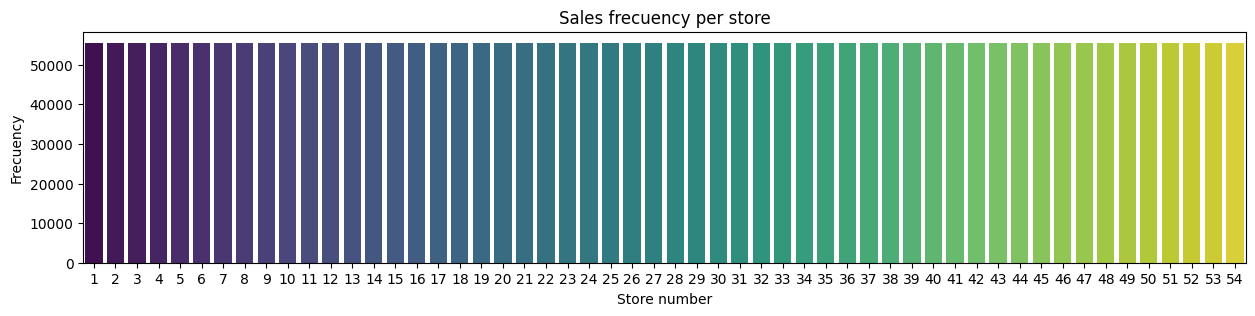

In [22]:
# numero de movimientos por tienda

store_data = df_train['store_nbr']
store_frecuency = store_data.value_counts().sort_index()

plt.figure(figsize=(15, 3))
sns.barplot(x=store_frecuency.index, y=store_frecuency.values, palette='viridis')

plt.title('Sales frecuency per store')
plt.xlabel('Store number')
plt.ylabel('Frecuency')
plt.show()

STORE_NBR RESUME

Tenemos la misma cantidad de movimientos por tienda y 54 tiendas distintas.

<font color='red' size=6>
    FAMILY
</font>

La familia es el tipo de producto que se está comercializando, por ende, se estudiará de la misma forma que store_nbr

In [23]:
# valores unicos

df_train['family'].sort_values(ascending=True).unique()

<StringArray>
[                'AUTOMOTIVE',                  'BABY CARE',
                     'BEAUTY',                  'BEVERAGES',
                      'BOOKS',               'BREAD/BAKERY',
                'CELEBRATION',                   'CLEANING',
                      'DAIRY',                       'DELI',
                       'EGGS',               'FROZEN FOODS',
                  'GROCERY I',                 'GROCERY II',
                   'HARDWARE',         'HOME AND KITCHEN I',
        'HOME AND KITCHEN II',            'HOME APPLIANCES',
                  'HOME CARE',                 'LADIESWEAR',
            'LAWN AND GARDEN',                   'LINGERIE',
           'LIQUOR,WINE,BEER',                  'MAGAZINES',
                      'MEATS',              'PERSONAL CARE',
               'PET SUPPLIES',    'PLAYERS AND ELECTRONICS',
                    'POULTRY',             'PREPARED FOODS',
                    'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES',
          

C:\Users\Facundo\AppData\Local\Temp\ipykernel_15716\3521051324.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=family_frecuency.index, y=family_frecuency.values, palette='viridis')


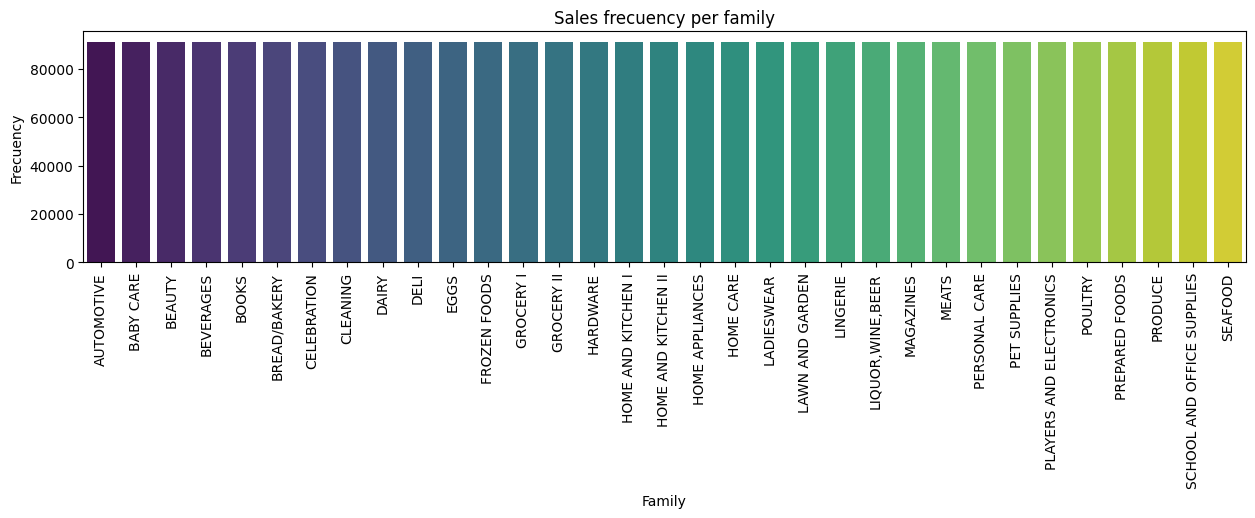

In [24]:
family_data = df_train['family']
family_frecuency = family_data.value_counts().sort_index()

plt.figure(figsize=(15, 3))
sns.barplot(x=family_frecuency.index, y=family_frecuency.values, palette='viridis')

plt.title('Sales frecuency per family')
plt.xlabel('Family')
plt.ylabel('Frecuency')
plt.xticks(rotation=90)
plt.show()

FAMILY RESUME

Las estadísticas son similares que store_nbr, 33 valores únicos y una tendencia plana en la frecuencia de cada una de las categorías. Esto muestra que los datos son sintéticos y no corresponden a la realidad, por lo que dificilmente pueda emplearse en la realidad.

En resumen, no se seguirá con el proyecto por la razón de que no serviría para emplearlo en la realidad.